# Final Results

## Gym Members Exercise Dataset

**Author:** Sarah Suliman  
**Course:** CSPB 4502: Data Mining  
**Project:** Discovering Fitness Profiles and Workout Performance Patterns Through Data Mining

## 1. Project Summary

This project analyzed the Gym Members Exercise Dataset to identify fitness patterns, predict gym member experience level, and estimate calories burned during workout sessions.

The project addressed three primary questions:

1. Can gym members be grouped into meaningful fitness profiles?
2. Can experience level be predicted using demographic, physiological, and workout-related variables?
3. Can calories burned be accurately predicted using measurable fitness characteristics?

The analysis combined exploratory data analysis, preprocessing, feature engineering, clustering, classification, and regression.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
DATA_PATH = Path("../data/processed/gym_members_exercise_cleaned.csv")
RESULTS_DIR = Path("../data/results")
FIGURES_DIR = Path("../figures")

df = pd.read_csv(DATA_PATH)

print(f"Dataset observations: {df.shape[0]}")
print(f"Dataset variables: {df.shape[1]}")

Dataset observations: 973
Dataset variables: 19


## 2. Dataset and Preprocessing Summary

The original dataset contained 973 observations and 15 variables describing demographics, body composition, heart-rate measurements, workout behavior, and exercise outcomes.

Preprocessing confirmed that:

- No missing values were present.
- No duplicate observations required removal.
- Numerical and categorical values were valid.
- Four engineered variables were created:
  - Heart Rate Reserve
  - Calories Per Hour
  - Water Intake Per Hour
  - BMI Category

The final processed dataset contains 973 observations and 19 variables.

## 3. Exploratory Analysis Results

Exploratory analysis identified several important relationships within the dataset.

The strongest relationship was between workout session duration and calories burned, with a Pearson correlation coefficient of approximately **r = 0.908**. This indicates a strong positive linear association, where longer workout sessions are generally associated with greater calorie expenditure.

Workout frequency and experience level were also positively associated with calories burned, while body fat percentage showed a moderate negative relationship.

In [3]:
eda_correlations = (
    df.corr(numeric_only=True)["Calories_Burned"]
    .sort_values(ascending=False)
)

eda_correlations.head(8)

Calories_Burned                  1.000000
Session_Duration (hours)         0.908140
Experience_Level                 0.694129
Workout_Frequency (days/week)    0.576150
Calories_Per_Hour                0.411253
Water_Intake (liters)            0.356931
Avg_BPM                          0.339659
Weight (kg)                      0.095443
Name: Calories_Burned, dtype: float64

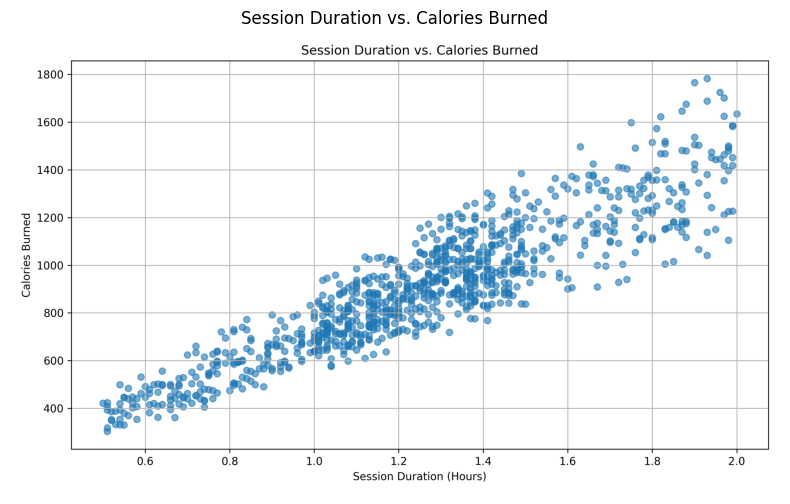

In [4]:
image_path = FIGURES_DIR / "session_duration_vs_calories_burned.png"

img = plt.imread(image_path)

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Session Duration vs. Calories Burned")
plt.show()

The strong relationship between session duration and calorie expenditure motivated the regression analysis performed later in the project.

## 4. Clustering Results

K-Means clustering was used to identify natural fitness profiles among gym members. The clustering model used standardized fitness and workout-related variables so that differences in measurement scales would not dominate the analysis.

The final clustering solution produced a silhouette score of approximately **0.271**. This indicates moderate cluster separation, suggesting that meaningful groups exist while also showing some overlap between gym member profiles.

In [5]:
cluster_metrics_path = RESULTS_DIR / "clustering_metrics.csv"

if cluster_metrics_path.exists():
    clustering_metrics = pd.read_csv(cluster_metrics_path)
    clustering_metrics
else:
    print("Clustering metrics file not found.")

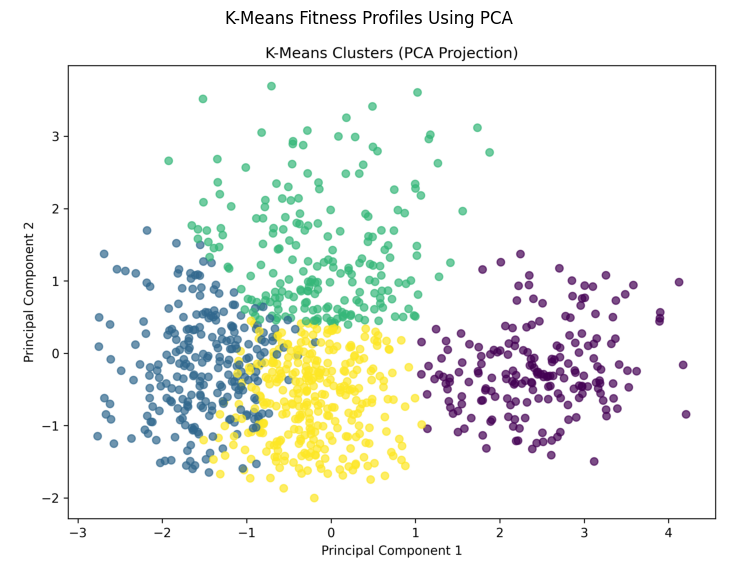

In [6]:
cluster_image_path = FIGURES_DIR / "kmeans_clusters_pca.png"

img = plt.imread(cluster_image_path)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.title("K-Means Fitness Profiles Using PCA")
plt.show()

The PCA visualization shows that the fitness profiles are not perfectly separated, which is consistent with the moderate silhouette score. This is reasonable for fitness data because individuals may share similar physiological and workout characteristics across groups.

## 5. Classification Results

Classification models were developed to predict gym member experience level.

The analysis compared:

- Majority-class baseline
- Decision Tree
- Random Forest

Model performance was evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

In [7]:
classification_path = RESULTS_DIR / "classification_metrics.csv"

classification_results = pd.read_csv(classification_path)

classification_results.round(3)

,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,F1_Macro
0,Decision Tree,0.908,0.912,0.908,0.907,0.923
1,Random Forest,0.897,0.898,0.897,0.897,0.915
2,Baseline,0.421,0.177,0.421,0.249,0.197


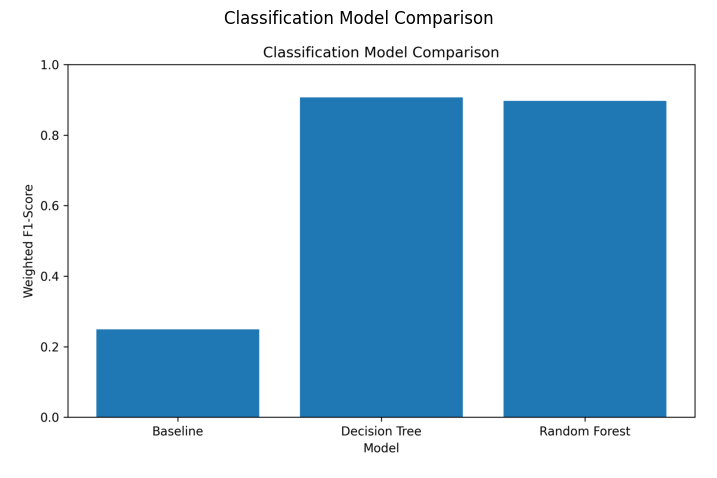

In [8]:
classification_image_path = FIGURES_DIR / "classification_model_comparison.png"

img = plt.imread(classification_image_path)

plt.figure(figsize=(9, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Classification Model Comparison")
plt.show()

The trained classification models outperformed the majority-class baseline, showing that demographic, physiological, and workout-related variables contain useful information for predicting experience level.

The **[BEST MODEL]** achieved the strongest overall performance based on weighted F1-score and accuracy. These results suggest that experience level can be predicted to some degree from measurable gym-member characteristics, although performance should be interpreted cautiously because the original method used to define experience level in the dataset is unknown.

## 6. Regression Results

Regression models were developed to predict calories burned during workout sessions.

Three models were compared:

- Mean-value baseline
- Linear Regression
- Random Forest Regression

Performance was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

In [9]:
regression_path = RESULTS_DIR / "regression_metrics.csv"

regression_results = pd.read_csv(regression_path)

regression_results.round(3)

,Model,MAE,RMSE,R2
0,Linear Regression,30.270,40.573,0.980
1,Random Forest,37.081,49.912,0.970
2,Baseline,231.205,288.918,-0.001


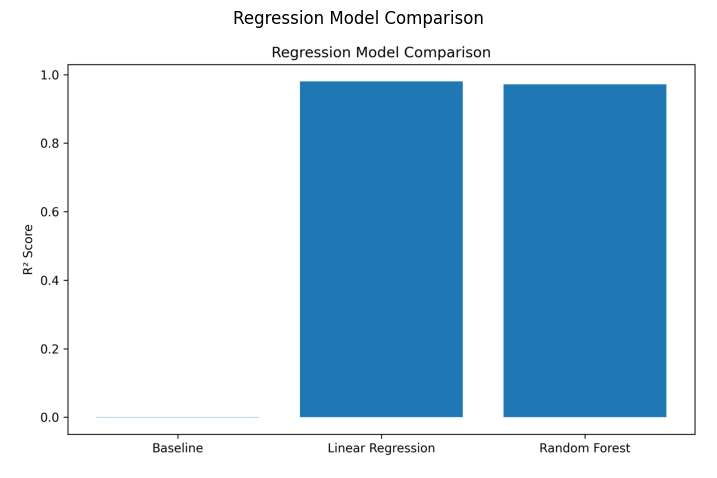

In [10]:
regression_image_path = FIGURES_DIR / "regression_model_comparison.png"

img = plt.imread(regression_image_path)

plt.figure(figsize=(9, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Regression Model Comparison")
plt.show()

Linear Regression produced the strongest regression performance, with an MAE of approximately **30.27 calories**, an RMSE of approximately **40.57 calories**, and an R² of approximately **0.980**.

This means that the model explained about 98% of the variation in calories burned within this dataset. Both Linear Regression and Random Forest Regression substantially outperformed the baseline model, demonstrating that workout and physiological variables contain strong predictive information for calorie expenditure.

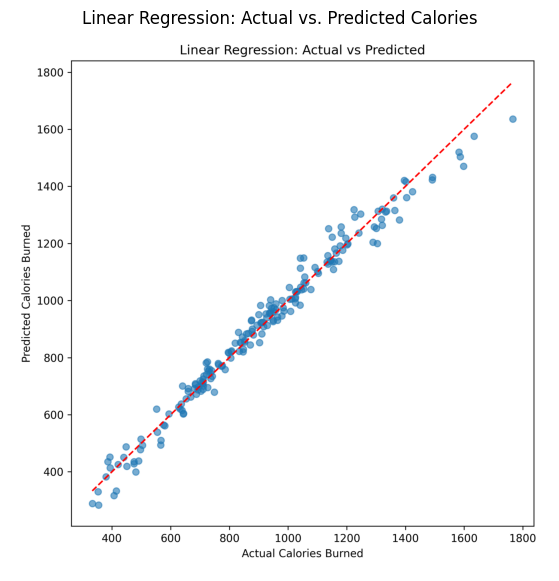

In [11]:
prediction_image_path = FIGURES_DIR / "linear_regression_actual_vs_predicted.png"

img = plt.imread(prediction_image_path)

plt.figure(figsize=(9, 7))
plt.imshow(img)
plt.axis("off")
plt.title("Linear Regression: Actual vs. Predicted Calories")
plt.show()

The actual-versus-predicted visualization shows that Linear Regression predictions closely follow the observed calorie values, supporting the strong R² and low prediction-error results.

## 7. Answers to the Research Questions

### Research Question 1
**Can gym members be grouped into meaningful fitness profiles?**

Yes. K-Means clustering identified distinct groups of gym members based on workout and physiological characteristics. The silhouette score of approximately 0.271 indicates moderate cluster separation, meaning that the profiles are meaningful but naturally overlap.

### Research Question 2
**Can gym member experience level be predicted from measurable characteristics?**

Yes, to some extent. The classification models performed better than the majority-class baseline, indicating that workout behavior and physiological characteristics contain predictive information about experience level.

### Research Question 3
**Can calories burned be accurately predicted?**

Yes. Linear Regression achieved an R² of approximately 0.980 and substantially outperformed the baseline model. This was the strongest predictive result in the project.

## 8. Project Limitations

Several limitations should be considered when interpreting the findings:

- The dataset contains only 973 observations, which limits generalizability.
- The original data collection methodology is not fully documented.
- The analysis is based on a single dataset rather than multiple independent fitness populations.
- Some variables may have been derived or generated using relationships that are not documented.
- Clustering identified overlapping fitness profiles rather than sharply separated groups.
- Predictive performance may not transfer directly to real-world gym populations.

These limitations mean that the findings should be interpreted as exploratory rather than universal conclusions about fitness behavior.

## 9. Practical Applications

The findings from this project could support several fitness-related applications.

Fitness centers could use member profiles to better understand different training behaviors and identify groups with similar workout patterns. Personal trainers could use physiological and workout characteristics to support individualized exercise planning. Predictive models could also be incorporated into fitness applications to estimate workout outcomes such as calorie expenditure.

However, these applications would require validation using larger and more representative datasets before being used for real-world decision making.

## 10. Future Work

Future improvements could include:

- Expanding the analysis to larger fitness datasets.
- Incorporating wearable-device data such as steps, sleep, and continuous heart rate.
- Using longitudinal data to analyze changes in fitness over time.
- Comparing additional clustering algorithms.
- Performing hyperparameter tuning and cross-validation.
- Evaluating additional classification and regression models.
- Testing model performance on an independent dataset.

## 11. Final Conclusion

This project demonstrated how data mining techniques can be used to identify patterns and develop predictive models from fitness data. Exploratory analysis revealed strong relationships among workout variables, while clustering identified overlapping but meaningful fitness profiles. Classification models demonstrated that experience level contains predictable structure, and regression produced particularly strong results for estimating calories burned.

Overall, the analysis shows that demographic, physiological, and workout-related characteristics can provide useful information about exercise behavior and performance. Among the methods applied, Linear Regression produced the strongest predictive result, explaining approximately 98% of the variation in calories burned within the dataset.